# Seminar 03 — Diffusion and Flow Matching on a Ring

**Version:** student · Python / PyTorch · Google Colab

The first six tasks are adapted from [zero2robot](https://github.com/kaushikb11/zero2robot/tree/main): three from
[chapter 1.4 (diffusion)](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.4_diffusion) and three from
[chapter 1.5 (flow matching)](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.5_flow). They train only on a synthetic
two-dimensional ring. Three additional exercises from
[chapter 1.8 (tiny VLA)](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.8_vla) train and inspect a model on PushT and
ALOHA. The training and sampling formulas are adapted from the original chapters.

Selected [upstream source files](zero2robot/) and their
[license](zero2robot/LICENSE) are bundled as references. Upstream code uses the
MIT License; the chapters' `prose/` content uses CC BY-NC-SA 4.0.

**Workflow:** run the ring setup cells and Tasks 1–6, then the VLA setup and
VLA Tasks 1–3. For prediction tasks,
choose `A`, `B`, or `C` *before* running the experiment. In the student version,
complete all `TODO` items and written interpretations. The teacher version has
solutions. Training a ring model from scratch may take a few minutes.

## Environment setup — run this first

The experiments below use NumPy, PyTorch, and Matplotlib. A GPU is optional.
No external dataset or simulator is needed: each training run creates its own
synthetic ring points. The bundled zero2robot repository is a source reference.

In [ ]:
import importlib.util, json, subprocess, sys
from pathlib import Path

missing = [name for name in ('numpy', 'torch', 'matplotlib')
           if importlib.util.find_spec(name) is None]
if missing:
    subprocess.run([sys.executable, '-m', 'pip', 'install', *missing], check=True)
import numpy as np
import torch
from torch import nn
from torch.nn import functional as F
import matplotlib.pyplot as plt

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
OUT = Path('/content/seminar03_ring_runs' if 'google.colab' in sys.modules
           else './seminar03_ring_runs').resolve()
OUT.mkdir(parents=True, exist_ok=True)
TOY_POINTS = 2000
TOY_ITERS = 1500
MODEL_DIM = 64
print('PyTorch:', torch.__version__, '| device:', DEVICE)

In [ ]:
import math

TIME_DIM = 32
X0_CLIP = 3.0

def make_ring(gen):
    angle = torch.rand(TOY_POINTS, generator=gen) * (2 * math.pi)
    points = torch.stack([angle.cos(), angle.sin()], dim=1)
    points += 0.03 * torch.randn((TOY_POINTS, 2), generator=gen)
    return points.to(DEVICE)

def noise(shape, gen):
    return torch.randn(shape, generator=gen).to(DEVICE)

def time_embed(t, scale=1.0):
    half = TIME_DIM // 2
    freq = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / half)
    angle = (t.float() * scale)[:, None] * freq[None]
    return torch.cat([angle.sin(), angle.cos()], dim=1)

class TimeMLP(nn.Module):
    def __init__(self, hidden, time_scale=1.0):
        super().__init__()
        self.time_scale = time_scale
        self.net = nn.Sequential(
            nn.Linear(2 + TIME_DIM, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(), nn.Linear(hidden, 2))

    def forward(self, x, t):
        return self.net(torch.cat([x, time_embed(t, self.time_scale)], dim=1))

def make_schedule(steps):
    u = torch.linspace(0, steps, steps + 1, device=DEVICE) / steps
    alpha_bar_full = torch.cos((u + 0.008) / 1.008 * math.pi / 2) ** 2
    alpha_bar_full /= alpha_bar_full[0].clone()
    beta = (1 - alpha_bar_full[1:] / alpha_bar_full[:-1]).clamp(1e-8, 0.999)
    alpha = 1 - beta
    alpha_bar = torch.cumprod(alpha, dim=0)
    alpha_bar_prev = torch.cat([torch.ones(1, device=DEVICE), alpha_bar[:-1]])
    posterior_var = beta * (1 - alpha_bar_prev) / (1 - alpha_bar)
    return dict(steps=steps, beta=beta, alpha=alpha, alpha_bar=alpha_bar,
                alpha_bar_prev=alpha_bar_prev,
                sqrt_alpha_bar=alpha_bar.sqrt(),
                sqrt_one_minus_alpha_bar=(1 - alpha_bar).sqrt(),
                posterior_sigma=posterior_var.clamp_min(1e-20).sqrt())

def diffusion_loss(model, clean, schedule, gen):
    t = torch.randint(schedule['steps'], (len(clean),), generator=gen).to(DEVICE)
    eps = noise(clean.shape, gen)
    noisy = (schedule['sqrt_alpha_bar'][t][:, None] * clean
             + schedule['sqrt_one_minus_alpha_bar'][t][:, None] * eps)
    return F.mse_loss(model(noisy, t), eps)

@torch.no_grad()
def sample_diffusion(model, count, schedule, gen):
    x = noise((count, 2), gen)
    for step in reversed(range(schedule['steps'])):
        t = torch.full((count,), step, device=DEVICE, dtype=torch.long)
        eps = model(x, t)
        alpha_bar = schedule['alpha_bar'][step]
        alpha_bar_prev = schedule['alpha_bar_prev'][step]
        clean = ((x - schedule['sqrt_one_minus_alpha_bar'][step] * eps)
                 / schedule['sqrt_alpha_bar'][step]).clamp(-X0_CLIP, X0_CLIP)
        mean = (schedule['beta'][step] * alpha_bar_prev.sqrt()
                / (1 - alpha_bar) * clean
                + (1 - alpha_bar_prev) * schedule['alpha'][step].sqrt()
                / (1 - alpha_bar) * x)
        x = mean + (schedule['posterior_sigma'][step] * noise((count, 2), gen)
                    if step > 0 else 0.0)
    return x

def flow_loss(model, clean, gen):
    t = torch.rand(len(clean), generator=gen).to(DEVICE)
    eps = noise(clean.shape, gen)
    point = (1 - t)[:, None] * eps + t[:, None] * clean
    return F.mse_loss(model(point, t), clean - eps)

@torch.no_grad()
def sample_flow(model, count, steps, gen):
    x = noise((count, 2), gen)
    dt = 1 / steps
    for i in range(steps):
        t = torch.full((count,), i * dt, device=DEVICE)
        x = x + dt * model(x, t)
    return x

def ring_stats(points):
    points = points.detach().cpu().numpy()
    radius = np.hypot(points[:, 0], points[:, 1])
    on_ring = np.abs(radius - 1) < 0.2
    sector = (np.floor((np.arctan2(points[:, 1], points[:, 0]) + np.pi)
                       / (2 * np.pi) * 8).astype(int) % 8)
    return float(radius.mean()), float(on_ring.mean()), int(np.unique(sector[on_ring]).size)

def plot_training_history(folder):
    path = folder / 'training_history.json'
    if not path.is_file():
        return
    points = json.loads(path.read_text())['checkpoints']
    if not points:
        return
    epochs = [point['iteration'] for point in points]
    losses = [point['loss'] for point in points]
    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.plot(epochs, losses, marker='o')
    ax.set(xlabel='Training iteration', ylabel='Prediction MSE',
           title=folder.name.replace('_', ' ') + ': ring training loss')
    ax.grid(alpha=.25)
    plt.show()

def metric_bars(names, values, title, ylabel):
    fig, ax = plt.subplots(figsize=(7, 3.5))
    bars = ax.bar(names, values, color=['#5a83db', '#df765a', '#54a994'][:len(names)])
    ax.bar_label(bars, fmt='%.2f', padding=3)
    ax.set_title(title); ax.set_ylabel(ylabel)
    plt.show()

## Concepts and measurements

| Term | Meaning |
|---|---|
| **MSE** | Mean squared error. A one-shot regressor minimizes it by predicting the conditional mean. |
| **DDPM** | Denoising diffusion probabilistic model; it learns to predict added noise. |
| **MLP** | Multilayer perceptron; the small neural network used in the experiments. |
| **ODE** | Ordinary differential equation; flow matching samples by integrating a learned velocity field. |

The ring is a continuous circle of valid two-dimensional points. Its eight
angular sectors are measurement bins, not eight separate classes. We measure
`modes_covered` (the number of sectors with on-ring samples), `mean_radius`
(the average distance from the empty center), and `ring_hit` (the fraction of
samples whose radius is within 0.2 of one).

Diffusion and flow matching predict different training targets, so compare
losses within one method rather than comparing their numeric values directly.

## Experiment roadmap

Each run generates 2,000 ring points and trains a fresh generative model. The
full diffusion and flow runs also train a separate one-shot MSE regressor on the
same point distribution. The regressor has no information about which ring
point to output, so its predictions tend toward the empty center. The
generative models start from random noise and aim to produce individual points
on the circle.

Task 2 trains a new diffusion model with two denoising steps; Task 5 samples
the already trained flow model with five Euler steps. The experiment cells save
ring metrics and sparse loss checkpoints under `seminar03_ring_runs/`. A rerun
reads the saved result; delete that run's folder to train it again. The plots
above and below show the ring geometry and the measured results.

## Why a single predicted action can fail

The ring represents many valid points. If the target can lie in any direction,
the MSE-optimal single prediction is their conditional mean: the empty center.
Generative methods start from random noise and produce individual ring points.

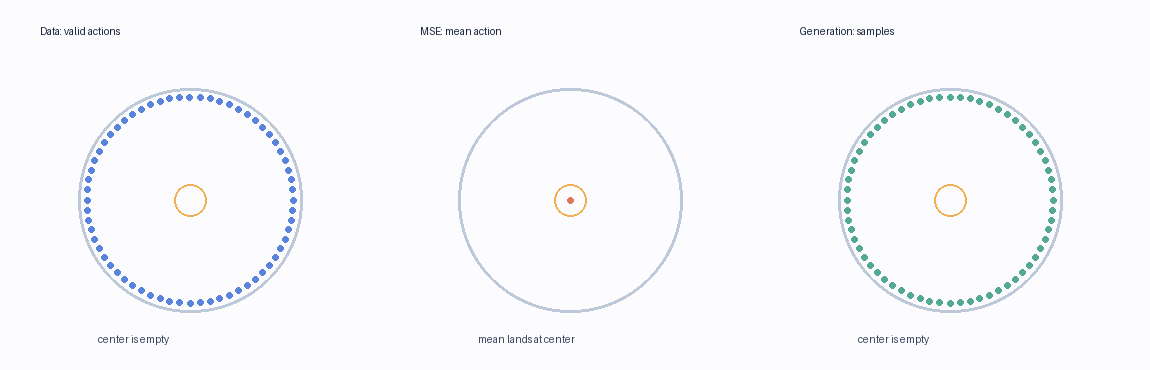

In [ ]:
rng = np.random.default_rng(0)
theta = rng.uniform(0, 2*np.pi, 2000)
ring = np.column_stack([np.cos(theta), np.sin(theta)]) + rng.normal(0, 0.03, (2000, 2))
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(ring[:, 0], ring[:, 1], s=2, alpha=.45, label='valid actions')
ax.scatter(*ring.mean(0), c='crimson', s=100, marker='x', label='MSE mean')
ax.set_aspect('equal'); ax.legend(); ax.set_title('Data and its mean'); plt.show()

## Part I. Diffusion

**Training.** Take a clean ring point $x_0$, choose a noise level $t$, and mix it
with random Gaussian noise $\epsilon$:
$x_t=\sqrt{\bar\alpha_t}x_0+\sqrt{1-\bar\alpha_t}\epsilon$.
The network sees only $x_t$ and $t$ and learns to predict the noise that was
added. Here $\bar\alpha_t$ is the scheduled fraction of original signal
remaining at level $t$; it is computed from
$\alpha_t=1-\beta_t$ and $\bar\alpha_t=\prod_{s=0}^{t}\alpha_s$.

**Inference (generating a new point).** No ring point is supplied to the trained
network. For each new sample, start with a random two-dimensional vector from
$\mathcal N(0,I)$. Then visit the noise levels in reverse order (in Task 1:
49, 48, ..., 0):

1. Give the current noisy vector and the current level $t$ to the network. It
   predicts the noise $\hat\epsilon_t$ in that vector.
2. Use that prediction to estimate where the clean point is:
   $\hat x_0=(x_t-\sqrt{1-\bar\alpha_t}\hat\epsilon_t)/\sqrt{\bar\alpha_t}$.
   The sampler clips this estimate to $[-3,3]$ on each coordinate.
3. Move from the current vector toward $\hat x_0$ using the DDPM posterior
   mean $\mu_t$ (the formula in Task 3). Then draw a new, independent vector
   $z\sim\mathcal N(0,I)$ and set the next vector to
   $\mu_t+\sigma_t z$, where $\sigma_t$ comes from the noise schedule.
   On the final step, output $\mu_t$ without adding random noise.

The output of the final step is one generated ring point. Repeating the process
with new starting noise gives many different points. During inference the
network weights stay fixed; only the sampled vector changes. In Task 2, the
two-step model is **retrained**, because its noise schedule differs from the
50-step model. The `sample_diffusion` function in the setup cell implements
this reverse loop; the diagram below reads from right to left during inference.

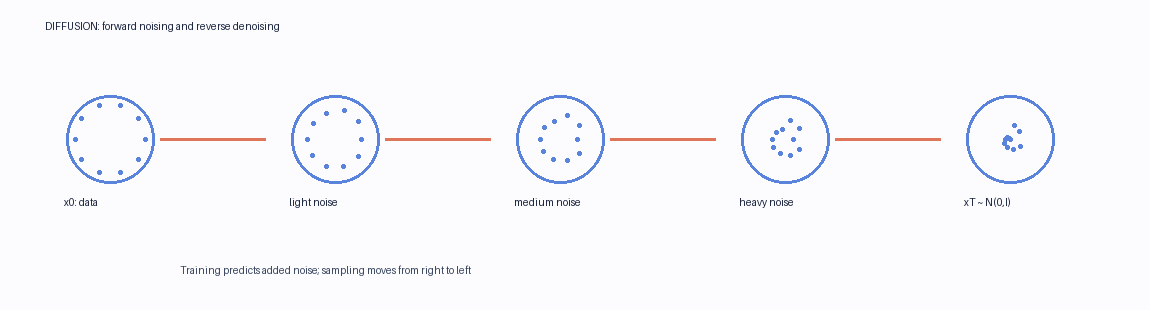

In [ ]:
# Forward-process visualization at fixed alpha-bar values.
fig, axes = plt.subplots(1, 4, figsize=(13, 3))
for ax, a in zip(axes, [0.95, 0.7, 0.3, 0.01]):
    noisy = np.sqrt(a)*ring + np.sqrt(1-a)*rng.normal(size=ring.shape)
    ax.scatter(noisy[:,0], noisy[:,1], s=1, alpha=.3)
    ax.set_title(f'alpha-bar={a}'); ax.set_aspect('equal'); ax.set_xlim(-3,3); ax.set_ylim(-3,3)
plt.tight_layout(); plt.show()

### What the training cells run

Task 1 trains a diffusion network to predict noise and a one-shot MSE regressor
on ring points. Task 2 trains a new diffusion network with a two-step schedule.
Task 4 trains a flow network to predict velocity and another MSE regressor.
Each cell generates data, updates its model weights, samples new points, and
writes ring-only metrics. The setup cell contains the shared schedule, loss,
sampler, and measurement formulas adapted from the source chapters.

### Task 1 — predict multimodality

**Source:** [bundled exercise](zero2robot/curriculum/phase1_imitation/ch1.4_diffusion/exercises/suggested/ex1_predict_multimodality.py) ·
[original exercise](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.4_diffusion/exercises/suggested/ex1_predict_multimodality.py).

Choose a prediction **before running**: A — both models cover all eight sectors;
B — diffusion covers the ring while regression lands near the center;
C — regression covers more. Then compare `modes_covered` and `mean_radius`.

**Procedure and evidence:** Write A, B, or C in `PREDICTION_D1`, then run the ring training cell. Read `toy_diffusion_modes_covered` and `toy_regress_modes_covered` alongside their mean radii. The first pair says how many valid directions were sampled; the radii reveal whether points stayed on the ring or collapsed into its empty center. The cell trains both models from scratch unless its ring result is already saved.

<details><summary>Hint</summary>

The source reference run reports 8/8 versus 0/8; the reduced exercise configuration preserves the direction of the effect.

</details>

In [ ]:
PREDICTION_D1 = None  # TODO: 'A', 'B', or 'C'
assert PREDICTION_D1 in ('A','B','C'), 'Record your prediction first'
folder = OUT / 'diffusion_full'
metric_path = folder / 'metrics.json'
if metric_path.is_file():
    d_full = json.loads(metric_path.read_text())
    print(f'Using saved ring results from {folder.name}.')
else:
    folder.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(0)
    gen = torch.Generator().manual_seed(0)
    training_ring = make_ring(gen)
    print('Training ring model from scratch:', folder.name, flush=True)
    schedule = make_schedule(50)
    model = TimeMLP(MODEL_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    checkpoints = []
    for iteration in range(TOY_ITERS):
        batch = torch.randint(TOY_POINTS, (256,), generator=gen)
        loss = diffusion_loss(model, training_ring[batch], schedule, gen)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if iteration % 500 == 0 or iteration == TOY_ITERS - 1:
            checkpoints.append({'iteration': iteration, 'loss': float(loss.item())})
            print(f'iteration {iteration:4d} diffusion_mse {loss.item():.5f}', flush=True)
    samples = sample_diffusion(model, TOY_POINTS, schedule, gen)
    radius, hit, modes = ring_stats(samples)
    d_full = {'denoising_steps': 50, 'toy_diffusion_mean_radius': radius,
              'toy_diffusion_ring_hit': hit, 'toy_diffusion_modes_covered': modes,
              'toy_final_loss': float(loss.item())}

    # A one-shot MSE regressor provides the same comparison as the source chapter.
    regressor = nn.Sequential(nn.Linear(2, MODEL_DIM), nn.SiLU(),
                              nn.Linear(MODEL_DIM, 2)).to(DEVICE)
    reg_optimizer = torch.optim.Adam(regressor.parameters(), lr=1e-3)
    for iteration in range(TOY_ITERS):
        batch = torch.randint(TOY_POINTS, (256,), generator=gen)
        reg_loss = F.mse_loss(regressor(noise((256, 2), gen)), training_ring[batch])
        reg_optimizer.zero_grad()
        reg_loss.backward()
        reg_optimizer.step()
    with torch.no_grad():
        reg_samples = regressor(noise((TOY_POINTS, 2), gen))
    reg_radius, reg_hit, reg_modes = ring_stats(reg_samples)
    d_full.update(toy_regress_mean_radius=reg_radius,
                  toy_regress_ring_hit=reg_hit,
                  toy_regress_modes_covered=reg_modes)
    (folder / 'training_history.json').write_text(json.dumps({'checkpoints': checkpoints}, indent=2) + '\n')
    metric_path.write_text(json.dumps(d_full, indent=2) + '\n')
plot_training_history(folder)
print({k: d_full[k] for k in ['toy_diffusion_modes_covered','toy_regress_modes_covered','toy_diffusion_mean_radius','toy_regress_mean_radius']})
metric_bars(['diffusion','MSE'], [d_full['toy_diffusion_modes_covered'], d_full['toy_regress_modes_covered']], 'Ring mode coverage', 'sectors out of 8')

**Interpretation:** Why does the regressor land where there are no training points?

*Your answer:* …

### Task 2 — predict the effect of two denoising steps

**Source:** [bundled exercise](zero2robot/curriculum/phase1_imitation/ch1.4_diffusion/exercises/suggested/ex2_predict_denoising_steps.py) ·
[original exercise](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.4_diffusion/exercises/suggested/ex2_predict_denoising_steps.py).

Choose a prediction: A — similar quality; B — the two-step run is worse;
C — it is better. Here **two steps** means two reverse denoising updates when
generating a point: first at $t=1$, then at $t=0$. The cell trains a separate
model with a matching two-level noise schedule; training still runs for 1500
optimizer iterations. Compare `ring_hit` and occupied sectors.

**Procedure and evidence:** Record `PREDICTION_D2` before running the cell. It reads the 50-step result from Task 1 and trains a new ring model with a two-step denoising schedule. Compare `denoising_steps`, `toy_diffusion_ring_hit`, and occupied sectors. A point can lie in a previously occupied direction while missing the ring, so both quality measures matter.

<details><summary>Hint</summary>

Inspect ring-hit as well as sectors: blurred samples can still occupy several angular sectors.

</details>

In [ ]:
PREDICTION_D2 = None  # TODO
assert PREDICTION_D2 in ('A','B','C'), 'Record your prediction first'
folder = OUT / 'diffusion_few_steps'
metric_path = folder / 'metrics.json'
if metric_path.is_file():
    d_few = json.loads(metric_path.read_text())
    print(f'Using saved ring results from {folder.name}.')
else:
    folder.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(0)
    gen = torch.Generator().manual_seed(0)
    training_ring = make_ring(gen)
    print('Training ring model from scratch:', folder.name, flush=True)
    schedule = make_schedule(2)
    model = TimeMLP(MODEL_DIM).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    checkpoints = []
    for iteration in range(TOY_ITERS):
        batch = torch.randint(TOY_POINTS, (256,), generator=gen)
        loss = diffusion_loss(model, training_ring[batch], schedule, gen)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if iteration % 500 == 0 or iteration == TOY_ITERS - 1:
            checkpoints.append({'iteration': iteration, 'loss': float(loss.item())})
            print(f'iteration {iteration:4d} diffusion_mse {loss.item():.5f}', flush=True)
    samples = sample_diffusion(model, TOY_POINTS, schedule, gen)
    radius, hit, modes = ring_stats(samples)
    d_few = {'denoising_steps': 2, 'toy_diffusion_mean_radius': radius,
              'toy_diffusion_ring_hit': hit, 'toy_diffusion_modes_covered': modes,
              'toy_final_loss': float(loss.item())}

    (folder / 'training_history.json').write_text(json.dumps({'checkpoints': checkpoints}, indent=2) + '\n')
    metric_path.write_text(json.dumps(d_few, indent=2) + '\n')
plot_training_history(folder)
print('full:', d_full['denoising_steps'], d_full['toy_diffusion_ring_hit'], d_full['toy_diffusion_modes_covered'])
print('2 steps:', d_few['denoising_steps'], d_few['toy_diffusion_ring_hit'], d_few['toy_diffusion_modes_covered'])
metric_bars(['full','2 steps'], [d_full['toy_diffusion_ring_hit'], d_few['toy_diffusion_ring_hit']], 'Samples on the ring', 'fraction of points')

**Interpretation:** Why does a low training loss for the two-step model not prove that it samples well?

*Your answer:* …

### Task 3 — complete the reverse DDPM step

**Source:** [bundled exercise](zero2robot/curriculum/phase1_imitation/ch1.4_diffusion/exercises/suggested/ex4_completion_reverse_step.py) ·
[original exercise](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.4_diffusion/exercises/suggested/ex4_completion_reverse_step.py).

Implement the mean of $q(x_{t-1}|x_t,x_0)$ from the source exercise:
$\mu=\frac{\beta_t\sqrt{\bar\alpha_{t-1}}}{1-\bar\alpha_t}x_0+
\frac{(1-\bar\alpha_{t-1})\sqrt{1-\beta_t}}{1-\bar\alpha_t}x_t$.

**Procedure and evidence:** Replace `NotImplementedError` with the two coefficients from the displayed posterior formula. The fixture checks the output shape and both numeric terms. After it passes, inspect the next plot: the clean-sample estimate and current noisy point contribute different weights at different reverse steps.

<details><summary>Hint</summary>

When `acp_prev=1`, the current `x_t` term has zero weight.

</details>

In [ ]:
def reverse_posterior_mean(x_t, x0, beta_t, acp_t, acp_prev):
    # TODO: implement the two-term blend
    raise NotImplementedError

x_t = np.array([[.2, -.4], [-.1, .3]])
x0 = np.array([[1., 0.], [0., 1.]])
result = reverse_posterior_mean(x_t, x0, .02, .6, .65)
assert result.shape == x_t.shape
assert np.allclose(result, .02*np.sqrt(.65)/.4*x0 + .35*np.sqrt(.98)/.4*x_t)

In [ ]:
# Weights of the two terms in the reverse mean under a valid schedule.
betas = np.linspace(.001, .08, 50)
alphas = 1 - betas
acp = np.cumprod(alphas)
prev = np.r_[1., acp[:-1]]
w_clean = betas*np.sqrt(prev)/(1-acp)
w_current = (1-prev)*np.sqrt(alphas)/(1-acp)
plt.plot(w_clean, label='estimated x0'); plt.plot(w_current, label='current xt')
plt.xlabel('t'); plt.ylabel('coefficient'); plt.title('Components of the reverse step')
plt.legend(); plt.show()

## Part II. Flow matching

**Training.** Take a clean ring point $x_0$, draw an independent Gaussian noise
point $\epsilon\sim\mathcal N(0,I)$, and choose a time $t$ uniformly in $[0,1]$.
Place a point on the straight line between them:
$x_t=(1-t)\epsilon+t x_0$. At $t=0$ it equals the noise point; at $t=1$ it
equals the ring point. For this pair, the line's velocity is the constant vector
$v^*=x_0-\epsilon$: the displacement needed to travel from noise to data in
one unit of time. The network sees $x_t$ and $t$ and learns to predict $v^*$
by minimizing $\|v_\theta(x_t,t)-v^*\|^2$ over many pairs. It never receives
the clean point as an input.

**Inference (generating a new point).** Start with a new random two-dimensional
vector $x^{(0)}\sim\mathcal N(0,I)$ at time $t=0$. Choose a number of Euler
steps $K$ and let $\Delta t=1/K$. For each $i=0,1,\ldots,K-1$:

1. Set $t_i=i/K$ and give the current point $x^{(i)}$ and $t_i$ to the trained
   network. It predicts a velocity $v_\theta(x^{(i)},t_i)$.
2. Follow that velocity for one small time interval:
   $x^{(i+1)}=x^{(i)}+\Delta t\,v_\theta(x^{(i)},t_i)$.

After $K$ updates, $x^{(K)}$ is one generated ring point. Repeating the process
with new starting noise gives different points. The network weights stay fixed
during inference. Task 4 samples the trained model with 50 Euler steps; Task 5
also samples **the same model** with 5 steps. The `sample_flow` function in the
setup cell implements this loop; the diagram below reads from left to right.

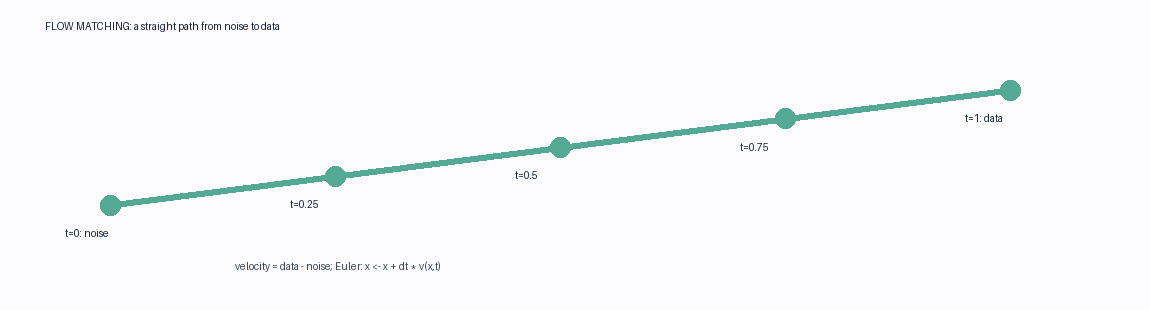

In [ ]:
# One straight path for fixed noise and data points.
path_noise, path_data = np.array([-1.3,-.7]), np.array([.8,1.1])
ts = np.linspace(0,1,6)
path = (1-ts[:,None])*path_noise + ts[:,None]*path_data
fig, ax = plt.subplots(figsize=(5,4)); ax.plot(path[:,0],path[:,1],'-o')
for t,p in zip(ts,path): ax.annotate(f'{t:.1f}',p)
ax.set_title('Interpolation: noise to data'); ax.set_aspect('equal'); plt.show()

### Task 4 — flow-matching multimodality

**Source:** [bundled exercise](zero2robot/curriculum/phase1_imitation/ch1.5_flow/exercises/suggested/ex1_predict_multimodality.py) ·
[original exercise](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.5_flow/exercises/suggested/ex1_predict_multimodality.py).

Choose a prediction: A — both models cover the ring; B — flow covers the ring
while the MSE regressor lands at the center; C — regression covers more. Run the flow training cell.

**Procedure and evidence:** Write `PREDICTION_F1` before running the flow training cell. Compare its ring-sector count and mean radius with the MSE regressor. Then compare this result with Task 1: the flow network predicts velocity instead of DDPM noise, but both generative objectives should avoid returning the conditional mean as a single action.

<details><summary>Hint</summary>

Compare with Task 1: the MSE regressor remains the same baseline method.

</details>

In [ ]:
PREDICTION_F1 = None  # TODO
assert PREDICTION_F1 in ('A','B','C'), 'Record your prediction first'
folder = OUT / 'flow_full'
metric_path = folder / 'metrics.json'
if metric_path.is_file():
    f_full = json.loads(metric_path.read_text())
    print(f'Using saved ring results from {folder.name}.')
else:
    folder.mkdir(parents=True, exist_ok=True)
    torch.manual_seed(0)
    gen = torch.Generator().manual_seed(0)
    training_ring = make_ring(gen)
    print('Training ring model from scratch:', folder.name, flush=True)
    model = TimeMLP(MODEL_DIM, time_scale=1000.0).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    checkpoints = []
    for iteration in range(TOY_ITERS):
        batch = torch.randint(TOY_POINTS, (256,), generator=gen)
        loss = flow_loss(model, training_ring[batch], gen)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        if iteration % 500 == 0 or iteration == TOY_ITERS - 1:
            checkpoints.append({'iteration': iteration, 'loss': float(loss.item())})
            print(f'iteration {iteration:4d} flow_mse {loss.item():.5f}', flush=True)
    samples = sample_flow(model, TOY_POINTS, 50, gen)
    radius, hit, modes = ring_stats(samples)
    low_step_samples = sample_flow(model, TOY_POINTS, 5, gen)
    _, low_hit, low_modes = ring_stats(low_step_samples)
    f_full = {'flow_steps': 50, 'toy_flow_mean_radius': radius,
              'toy_flow_ring_hit': hit, 'toy_flow_modes_covered': modes,
              'toy_flow_lowstep_steps': 5,
              'toy_flow_lowstep_ring_hit': low_hit,
              'toy_flow_lowstep_modes_covered': low_modes,
              'toy_final_loss': float(loss.item())}

    # A one-shot MSE regressor provides the same comparison as the source chapter.
    regressor = nn.Sequential(nn.Linear(2, MODEL_DIM), nn.SiLU(),
                              nn.Linear(MODEL_DIM, 2)).to(DEVICE)
    reg_optimizer = torch.optim.Adam(regressor.parameters(), lr=1e-3)
    for iteration in range(TOY_ITERS):
        batch = torch.randint(TOY_POINTS, (256,), generator=gen)
        reg_loss = F.mse_loss(regressor(noise((256, 2), gen)), training_ring[batch])
        reg_optimizer.zero_grad()
        reg_loss.backward()
        reg_optimizer.step()
    with torch.no_grad():
        reg_samples = regressor(noise((TOY_POINTS, 2), gen))
    reg_radius, reg_hit, reg_modes = ring_stats(reg_samples)
    f_full.update(toy_regress_mean_radius=reg_radius,
                  toy_regress_ring_hit=reg_hit,
                  toy_regress_modes_covered=reg_modes)
    (folder / 'training_history.json').write_text(json.dumps({'checkpoints': checkpoints}, indent=2) + '\n')
    metric_path.write_text(json.dumps(f_full, indent=2) + '\n')
plot_training_history(folder)
print({k: f_full[k] for k in ['toy_flow_modes_covered','toy_regress_modes_covered','toy_flow_mean_radius','toy_regress_mean_radius']})
metric_bars(['flow','MSE'], [f_full['toy_flow_modes_covered'], f_full['toy_regress_modes_covered']], 'Ring mode coverage', 'sectors out of 8')

**Interpretation:** How do Tasks 1 and 4 connect multimodality to the objective?

*Your answer:* …

### Task 5 — compare small step budgets

**Source:** [bundled exercise](zero2robot/curriculum/phase1_imitation/ch1.5_flow/exercises/suggested/ex2_predict_flow_vs_diffusion_steps.py) ·
[original exercise](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.5_flow/exercises/suggested/ex2_predict_flow_vs_diffusion_steps.py).

Choose a prediction: A — neither covers the ring; B — flow at five steps
covers more sectors than two-step diffusion; C — diffusion covers more. Comparing
five steps with two is **not** a matched-step quality comparison.

**Procedure and evidence:** Record `PREDICTION_F2`, then compare the five-step sample from the Task 4 flow network with the two-step diffusion run from Task 2. No new flow training happens in this cell: `toy_flow_lowstep_modes_covered` was measured by resampling the same trained network. Explain why this shows that flow's sampling step count can change after training, and why the unequal step budgets do not establish matched-step superiority.

<details><summary>Hint</summary>

`toy_flow_lowstep_*` comes from the **same trained flow network** as the full-step metrics.

</details>

In [ ]:
PREDICTION_F2 = None  # TODO
assert PREDICTION_F2 in ('A','B','C'), 'Record your prediction first'
print('flow, 5 steps:', f_full['toy_flow_lowstep_modes_covered'], 'of 8')
print('diffusion, 2 steps:', d_few['toy_diffusion_modes_covered'], 'of 8')
print('flow train loss:', f_full['toy_final_loss'])
metric_bars(['flow: 5','diffusion: 2'], [f_full['toy_flow_lowstep_modes_covered'], d_few['toy_diffusion_modes_covered']], 'Small step budget', 'sectors out of 8')

**Interpretation:** What advantage of flow is actually measured here?

*Your answer:* …

### Task 6 — complete the Euler sampler

**Source:** [bundled exercise](zero2robot/curriculum/phase1_imitation/ch1.5_flow/exercises/suggested/ex4_completion_euler_sampler.py) ·
[original exercise](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.5_flow/exercises/suggested/ex4_completion_euler_sampler.py).

Implement `steps` updates of $x\leftarrow x+\Delta t\,v(x,t)$, where
$\Delta t=1/steps$ and $t=i\Delta t$. Evaluate velocity at the current `x` and
`t` on every step.

**Procedure and evidence:** Copy the initial noise array so the caller's input is preserved. Let `dt=1/steps`; for each `i`, call `velocity(x, i*dt)` on the current point, then update `x`. The constant-velocity fixture must land exactly on `target`. For a learned, position-dependent field, changing the number of steps changes the approximation quality.

<details><summary>Hint</summary>

A constant velocity of `target-start` should reach `target` for any positive step count.

</details>

In [ ]:
def euler_sample(velocity, x0_noise, steps):
    # TODO: implement the Euler loop
    raise NotImplementedError

start = np.array([[-1.,0.],[0.,-1.]])
target = np.array([[1.,0.],[0.,1.]])
answer = euler_sample(lambda x,t: target-start, start, 5)
assert np.allclose(answer, target)

## Comparison and submission

Summarize ring mode coverage, mean radius, and ring-hit fraction for diffusion
and flow. Explain how their training targets and sampling steps differ, and
what the two-step and five-step experiments establish.

**Sources:** [zero2robot: diffusion](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.4_diffusion),
[zero2robot: flow matching](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.5_flow),
[original notebooks](https://github.com/kaushikb11/zero2robot/tree/main/notebooks).

In [ ]:
rows = [
    ('diffusion', d_full['toy_diffusion_modes_covered'], d_full['toy_diffusion_mean_radius'], d_full['toy_diffusion_ring_hit']),
    ('flow', f_full['toy_flow_modes_covered'], f_full['toy_flow_mean_radius'], f_full['toy_flow_ring_hit']),
]
print('method      sectors  radius  ring_hit')
for name, modes, radius, hit in rows:
    print(f'{name:11s} {modes:7d} {radius:7.2f} {hit:9.2f}')

## Part III. Tiny vision-language-action model

These three exercises adapt [chapter 1.8](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.8_vla). The model fuses an
instruction, a camera image, and robot state, then predicts a flow
velocity for an action. It trains from scratch on **both PushT and ALOHA**. Unlike
the ring exercises, this section runs MuJoCo simulations. The sighted model
trains its CNN encoder from random initialization together with the policy.
The blind model receives no visual feature. No pretrained vision model is used.

Run the following setup and data cells before VLA Tasks 1–3. The notebook contains
the data assembly, model, training, and evaluation code. Only the simulator
classes and scripted demonstration experts are imported from the bundled
[zero2robot source](zero2robot/). A GPU speeds up neural-network operations;
MuJoCo simulation and rendering still run on the CPU. The default experiment
uses 60 demonstrations per task and 200 training epochs. Set `VLA_SMOKE = True`
for a quick code check; its results are too small for the exercise conclusions.

### TinyVLA architecture

The figure shows the configuration used below. The upper panel follows one
action through the model; the lower panel shows its training signal. The
camera CNN is trained in the sighted run.

**Action at one control step (10 Hz):**

| Task | Action vector | Meaning |
| --- | --- | --- |
| PushT | `[vx, vy]` | Planar target velocity of the pusher (m/s). |
| ALOHA | `[right_vx, right_vy, right_grip, left_vx, left_vy, left_grip]` | Planar target velocities of both grippers (m/s) and their open/close commands. |

Action values are clipped to `[-1, 1]`. For each ALOHA gripper, `-1` means open
and `+1` means closed. This is a simplified planar ALOHA environment, not full
joint control of a physical robot. TinyVLA always predicts six values: all six
are used for ALOHA, while only the first two are used for PushT. The other four
PushT dimensions are masked in the training loss.

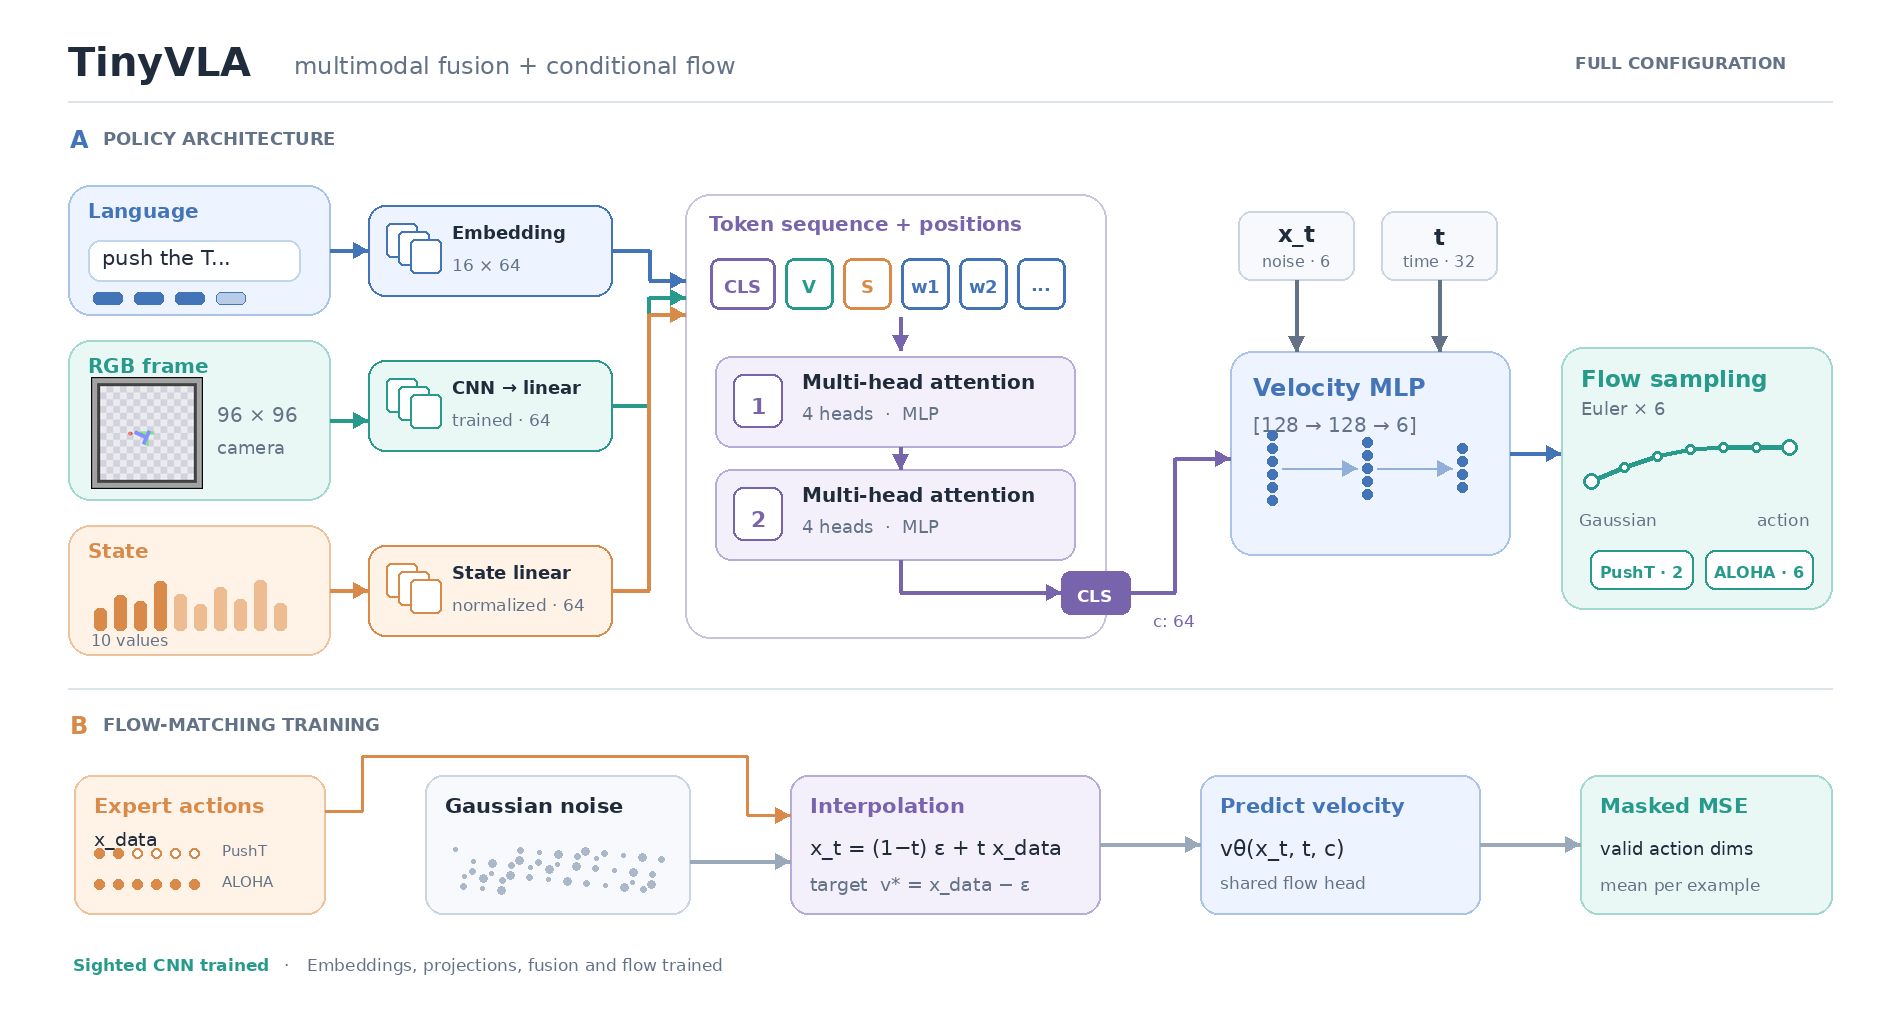

### Scripted demonstrations used for training

These videos show one successful demonstration from each scripted expert at
seed 0. The notebook trains on many such episodes. The videos illustrate the
tasks and data collection; they are **expert trajectories**, not outputs of
the trained TinyVLA. The model receives 96×96 camera frames, while these
previews are rendered at 256×256 for viewing.

<figure style="display:inline-block;margin:0 20px 12px 0"><video controls playsinline preload="metadata" width="400" src="..."></video><figcaption>PushT: push the T block to its goal</figcaption></figure>
<figure style="display:inline-block;margin:0 20px 12px 0"><video controls playsinline preload="metadata" width="400" src="..."></video><figcaption>ALOHA: transfer the cube between arms</figcaption></figure>

### VLA environment

The cell finds the bundled repository, or clones the pinned source commit in
Colab when only the notebook was uploaded. It installs MuJoCo if needed. Run it
before importing the environments so headless rendering can use EGL on Linux.

In [ ]:
import importlib.util, os, subprocess, sys, json, math
from pathlib import Path

if sys.platform.startswith('linux'):
    os.environ.setdefault('MUJOCO_GL', 'egl')
candidates = [
    Path.cwd() / '03-diffusion-policy-flow-matching' / 'zero2robot',
    Path.cwd() / 'zero2robot',
    Path.cwd().parent / '03-diffusion-policy-flow-matching' / 'zero2robot',
    Path.cwd().parent / 'zero2robot',
    Path('/content/zero2robot'),
]
VLA_REPO = next((p.resolve() for p in candidates if
                 (p / 'curriculum/phase1_imitation/ch1.8_vla/vla.py').is_file()), None)
if VLA_REPO is None and 'google.colab' in sys.modules:
    VLA_REPO = Path('/content/zero2robot')
    subprocess.run(['git', 'clone', '-q', 'https://github.com/kaushikb11/zero2robot.git',
                    str(VLA_REPO)], check=True)
    subprocess.run(['git', '-C', str(VLA_REPO), 'checkout', '-q',
                    'ad9cfc9e933e01a619f809a70e117b1de4b2d70d'], check=True)
if VLA_REPO is None:
    raise FileNotFoundError('Open the notebook beside the bundled zero2robot directory.')
if importlib.util.find_spec('mujoco') is None:
    subprocess.run([sys.executable, '-m', 'pip', 'install', 'mujoco==3.10.0'], check=True)
import mujoco
import numpy as np
import torch
from torch import nn
if str(VLA_REPO) not in sys.path:
    sys.path.insert(0, str(VLA_REPO))
from curriculum.common.envs.pusht.pusht_env import PushTEnv
from curriculum.common.envs.pusht.scripted_expert import ScriptedExpert as PushtExpert
from curriculum.common.envs.aloha_cube.aloha_cube_env import AlohaCubeEnv
from curriculum.common.envs.aloha_cube.scripted_expert import ScriptedExpert as AlohaExpert

VLA_SMOKE = False  # True only for a quick wiring check, not for interpreting results
VLA_CONFIG = dict(seed=0, episodes_per_task=60, epochs=200, batch_size=128,
                  model_dim=64, layers=2, heads=4, hidden=128, flow_steps=6,
                  eval_episodes=12, feature_dim=64, conv_width=16)
if VLA_SMOKE:
    VLA_CONFIG.update(episodes_per_task=2, epochs=2, model_dim=16, layers=1,
                      heads=2, hidden=16, flow_steps=2, eval_episodes=2,
                      feature_dim=16, conv_width=8)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
VLA_OUT = Path('/content/seminar03_vla_runs' if 'google.colab' in sys.modules
               else './seminar03_vla_runs').resolve() / ('smoke' if VLA_SMOKE else 'full')
VLA_OUT.mkdir(parents=True, exist_ok=True)
STATE_DIM, ACT_DIM, ACT_DIM_MAX = 10, 6, 6
MAX_TOKENS, IMG_HW, PAD_ID = 16, 96, 0
TIME_DIM, TIME_SCALE = 32, 1000.0
print('VLA source:', VLA_REPO, '| device:', device, '| smoke:', VLA_SMOKE)

### Assemble the multi-task dataset

The next cells replay scripted demonstrations, attach an instruction to each
episode, and save 96×96 camera frames. An initial random CNN projection provides
feature-normalization statistics; during sighted training the CNN weights are
updated from the raw frames. PushT actions
use two coordinates; ALOHA actions use six. A mask marks valid coordinates.
The generated dataset and encoder weights are saved so rerunning the notebook
does not repeat simulation. This is the same data recipe as chapter 1.7.

In [ ]:
# Two tasks, two embodiments, ONE pile — that is the multi-task point. A real VLA
# (RT-X, OpenVLA) mixes dozens of datasets; the idea is already visible with two.
# Each task brings its OWN env, its OWN scripted expert (the SAME experts
# gen_demos.py writes the LeRobot v3 datasets with — we replay them in-process here
# so we can render frames without a video-decode dependency), its action
# dimensionality, and a set of paraphrase instructions.
TASKS = [
    {
        "name": "pusht",
        "env": PushTEnv, "expert": PushtExpert, "act_dim": PushTEnv.ACT_DIM,
        "templates": [
            "push the t block onto the target",
            "slide the tee onto the goal",
            "move the t shape to the target pose",
            "push the block until it covers the target",
        ],
    },
    {
        "name": "aloha",
        "env": AlohaCubeEnv, "expert": AlohaExpert, "act_dim": AlohaCubeEnv.ACT_DIM,
        "templates": [
            "transfer the cube to the other arm",
            "hand the cube from the right arm to the left arm",
            "pick up the cube and pass it to the left gripper",
            "carry the cube across and place it on the target",
        ],
    },
]


def collect_task(task: dict, episodes: int, seed: int, stride: int):
    """Replay the scripted expert for `episodes` episodes; return per-frame states,
    padded actions, 96x96 frames, and the episode index of each frame.

    Deterministic given seed: episode e uses env+expert seed (seed + e), exactly
    the reproducibility contract gen_demos.py relies on. Actions live in the task's
    native dimensionality (2 for pusht, 6 for aloha); we zero-pad to ACT_DIM_MAX so
    both tasks share one action tensor — the honest cost of mixing embodiments.
    """
    env = task["env"]()
    states, actions, frames, ep_index = [], [], [], []
    for e in range(episodes):
        obs = env.reset(seed + e)
        expert = task["expert"](noise=0.0, seed=seed + e)
        step, done = 0, False
        while not done:
            action = expert.action(env)
            if step % stride == 0:  # subsample: consecutive frames are near-duplicates
                padded = np.zeros(ACT_DIM_MAX, dtype=np.float32)
                padded[: task["act_dim"]] = action[: task["act_dim"]]
                states.append(obs.astype(np.float32))
                actions.append(padded)
                frames.append(env.render_frame(IMG_HW, IMG_HW))
                ep_index.append(e)
            obs, _, done, _ = env.step(action)
            step += 1
    return (np.asarray(states, np.float32), np.asarray(actions, np.float32),
            np.asarray(frames, np.uint8), np.asarray(ep_index, np.int64))

In [ ]:
# A VLA reads words, and words must become integers. We build the WHOLE tokenizer
# from scratch: a fixed WORD-LEVEL vocab (no BPE, no HF tokenizers), four special
# ids, pad/truncate to MAX_TOKENS. It is tiny (~40 words) on purpose — a real VLA
# uses a 30k+ subword vocab from a pretrained language model, which is one of the
# things chapter 1.8 reaches for. Here the point is the MECHANISM, laid bare.
_SPECIALS = ["<pad>", "<unk>", "<bos>", "<eos>"]  # ids 0..3, by construction
# --break leak appends one of these compass words per FRAME. They must be IN vocab:
# an out-of-vocab word would collapse to <unk> and leak nothing.
_DIRECTIONS = ["east", "northeast", "north", "northwest",
               "west", "southwest", "south", "southeast"]


class Tokenizer:
    """Word-level tokenizer over a FIXED vocab. Deterministic: the vocab is the
    sorted set of corpus words, so the same corpus always yields the same ids."""

    def __init__(self, corpus: list[str]) -> None:
        words = sorted({w for text in corpus for w in text.split()})
        self.itos = _SPECIALS + words              # index -> string
        self.stoi = {w: i for i, w in enumerate(self.itos)}

    @property
    def vocab_size(self) -> int:
        return len(self.itos)

    def encode(self, text: str) -> np.ndarray:
        # [BOS] word ids... [EOS], unknown words -> <unk>, then pad/truncate.
        ids = [self.stoi["<bos>"]]
        ids += [self.stoi.get(w, self.stoi["<unk>"]) for w in text.split()]
        ids.append(self.stoi["<eos>"])
        ids = ids[:MAX_TOKENS] + [self.stoi["<pad>"]] * (MAX_TOKENS - len(ids))
        return np.asarray(ids[:MAX_TOKENS], dtype=np.int64)


def direction_word(action_xy: np.ndarray) -> str:
    """8-way compass word for a 2D action vector; the leak template appends it."""
    sector = int(np.round(np.arctan2(action_xy[1], action_xy[0]) / (np.pi / 4))) % 8
    return _DIRECTIONS[sector]

In [ ]:
class VisionEncoder(nn.Module):
    # Small CNN initialized from scratch; the sighted run trains these weights.
    def __init__(self, width, feature_dim):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, width, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(width, 2 * width, 3, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(2 * width, 4 * width, 3, stride=2, padding=1), nn.ReLU(),
            nn.AdaptiveAvgPool2d(1),
        )
        self.head = nn.Linear(4 * width, feature_dim)

    def forward(self, images_uint8):
        x = images_uint8.to(torch.float32).permute(0, 3, 1, 2) / 127.5 - 1.0
        return self.head(self.stem(x).flatten(1))

@torch.no_grad()
def encode_frames(vision_model, frames, device, batch=256):
    features = []
    for start in range(0, len(frames), batch):
        images = torch.from_numpy(frames[start:start+batch]).to(device)
        features.append(vision_model(images).cpu().numpy())
    return np.concatenate(features).astype(np.float32)

In [ ]:
VLA_DATA_DIR = VLA_OUT / 'data'
VLA_DATA_DIR.mkdir(parents=True, exist_ok=True)
VLA_DATA_FILE = VLA_DATA_DIR / 'vla_dataset.npz'
VLA_FRAMES_FILE = VLA_DATA_DIR / 'camera_frames.npy'
VLA_MANIFEST_FILE = VLA_DATA_DIR / 'manifest.json'
VLA_ENCODER_FILE = VLA_DATA_DIR / 'vision_encoder.pt'

# Reuse one seeded CNN initialization across dataset preparation and training.
# The training class below enables gradients through the same layers.
torch.manual_seed(VLA_CONFIG['seed'])
initial_encoder = VisionEncoder(VLA_CONFIG['conv_width'], VLA_CONFIG['feature_dim']).to(device)
if VLA_ENCODER_FILE.is_file():
    initial_encoder.load_state_dict(torch.load(VLA_ENCODER_FILE, map_location=device, weights_only=True))
else:
    torch.save(initial_encoder.state_dict(), VLA_ENCODER_FILE)
initial_encoder.eval()
initial_encoder.requires_grad_(False)  # saved initialization, not the sighted policy CNN

corpus = [text for task in TASKS for text in task['templates']] + _DIRECTIONS + ['moving']
tokenizer = Tokenizer(corpus)
if (not VLA_DATA_FILE.is_file() or not VLA_MANIFEST_FILE.is_file()
        or not VLA_FRAMES_FILE.is_file()):
    piles = []
    for task in TASKS:
        print('Collecting demonstrations:', task['name'], flush=True)
        states_i, actions_i, frames_i, episode_i = collect_task(
            task, VLA_CONFIG['episodes_per_task'], VLA_CONFIG['seed'], stride=2)
        features_i = encode_frames(initial_encoder, frames_i, device)
        piles.append((states_i, actions_i, features_i, episode_i, frames_i))
    states = np.concatenate([pile[0] for pile in piles])
    actions = np.concatenate([pile[1] for pile in piles])
    image_feats = np.concatenate([pile[2] for pile in piles])
    np.save(VLA_FRAMES_FILE, np.concatenate([pile[4] for pile in piles]))
    task_ids = np.concatenate([np.full(len(pile[0]), i, dtype=np.int64)
                               for i, pile in enumerate(piles)])
    episode_ids = np.concatenate([pile[3] for pile in piles])
    instructions = []
    for i in range(len(states)):
        task = TASKS[task_ids[i]]
        variant = (VLA_CONFIG['seed'] + task_ids[i] * 7919 + episode_ids[i]) % len(task['templates'])
        instructions.append(task['templates'][variant])
    tokens = np.stack([tokenizer.encode(text) for text in instructions])
    action_mask = np.zeros((len(states), ACT_DIM), np.float32)
    for i, task in enumerate(TASKS):
        action_mask[task_ids == i, :task['act_dim']] = 1.0
    np.savez(VLA_DATA_FILE, instruction_tokens=tokens, image_features=image_feats,
             state=states, action=actions, action_mask=action_mask, task_id=task_ids)
    manifest = {'seed': VLA_CONFIG['seed'],
                'episodes_per_task': VLA_CONFIG['episodes_per_task'],
                'feature_dim': VLA_CONFIG['feature_dim'], 'vocab': tokenizer.itos,
                'tasks': [{'name': task['name'], 'templates': task['templates']}
                          for task in TASKS]}
    VLA_MANIFEST_FILE.write_text(json.dumps(manifest, indent=2) + '\n')
else:
    manifest = json.loads(VLA_MANIFEST_FILE.read_text())
    assert manifest['seed'] == VLA_CONFIG['seed']
    assert manifest['episodes_per_task'] == VLA_CONFIG['episodes_per_task']
    assert manifest['feature_dim'] == VLA_CONFIG['feature_dim']
    assert manifest['vocab'] == tokenizer.itos
    print('Using saved VLA demonstrations:', VLA_DATA_FILE)

with np.load(VLA_DATA_FILE) as data:
    tokens_np = data['instruction_tokens'].astype(np.int64)
    image_feats = data['image_features'].astype(np.float32)
    states = data['state'].astype(np.float32)
    actions = data['action'].astype(np.float32)
    act_mask_np = data['action_mask'].astype(np.float32)
    task_ids = data['task_id'].astype(np.int64)
frames_np = np.load(VLA_FRAMES_FILE, mmap_mode='r')
assert len(frames_np) == len(states)
vocab = manifest['vocab']
feature_dim = VLA_CONFIG['feature_dim']
valid = act_mask_np.astype(bool)
act_mean = np.array([actions[valid[:, j], j].mean() if valid[:, j].any() else 0.0
                     for j in range(ACT_DIM)], np.float32)
act_std = np.array([actions[valid[:, j], j].std() if valid[:, j].any() else 1.0
                    for j in range(ACT_DIM)], np.float32)
act_std = np.where(act_std < 1e-4, np.float32(1.0), act_std)
state_min = states.min(0)
state_range = np.where(states.max(0) - state_min < 1e-4, np.float32(1.0),
                       states.max(0) - state_min)
feat_mean = image_feats.mean(0)
feat_std = np.where(image_feats.std(0) < 1e-4, np.float32(1.0), image_feats.std(0))
STATS = {'act_mean': act_mean, 'act_std': act_std, 'state_min': state_min,
         'state_range': state_range, 'feat_mean': feat_mean, 'feat_std': feat_std}
act_mean_t = torch.from_numpy(act_mean).to(device)
act_std_t = torch.from_numpy(act_std).to(device)
print('Training examples:', len(states), '| PushT:', int((task_ids == 0).sum()),
      '| ALOHA:', int((task_ids == 1).sum()), '| vocabulary:', len(vocab))

### Fuse language, vision, and state; train the action head

The model code below is copied into this notebook from the source chapter.
`Block` performs scaled dot-product self-attention. The CLS output conditions
a flow-matching velocity network. The flow loss averages over the valid action
coordinates of **each example**, then over examples, so PushT and ALOHA frames
have equal weight. The later bug-hunt exercise isolates this reduction.

In [ ]:
def encode_instruction(text):
    return tokenizer.encode(text)

# The tiny VLM + flow head, from scratch. No transformers, no einops — a transformer
# block is a from-scratch multi-head attention (Q,K,V projections, a scaled dot-product
# softmax, an output projection) plus an MLP, with pre-norm residuals. That is the whole
# "backbone"; the lesson is the FUSION, not a big architecture.
def sinusoidal_embed(t: torch.Tensor, dim: int) -> torch.Tensor:
    """Continuous flow time (B,) -> (B, dim) sinusoidal features (ch1.5 / ch1.4)."""
    half = dim // 2
    freqs = torch.exp(-math.log(10000.0) * torch.arange(half, device=t.device) / half)
    ang = t.float()[:, None] * freqs[None]
    return torch.cat([ang.sin(), ang.cos()], dim=1)


class Block(nn.Module):
    """One pre-norm transformer block: self-attention that lets vision, state, and each
    word token exchange information, then a per-token MLP. Built from nn.Linear only."""

    def __init__(self, dim: int, heads: int) -> None:
        super().__init__()
        self.heads = heads
        self.ln1, self.ln2 = nn.LayerNorm(dim), nn.LayerNorm(dim)
        self.qkv = nn.Linear(dim, 3 * dim)
        self.proj = nn.Linear(dim, dim)
        self.mlp = nn.Sequential(nn.Linear(dim, 4 * dim), nn.GELU(), nn.Linear(4 * dim, dim))
        self.last_attn = None  # CLS-token attention over the sequence, for the rerun viz

    def forward(self, x: torch.Tensor, key_pad: torch.Tensor) -> torch.Tensor:
        B, L, dim = x.shape
        h, hd = self.heads, dim // self.heads
        qkv = self.qkv(self.ln1(x)).reshape(B, L, 3, h, hd).permute(2, 0, 3, 1, 4)
        q, k, v = qkv[0], qkv[1], qkv[2]                      # each (B, h, L, hd)
        scores = (q @ k.transpose(-2, -1)) / math.sqrt(hd)   # (B, h, L, L)
        scores = scores.masked_fill(key_pad[:, None, None, :], float("-inf"))  # ignore <pad> keys
        attn = scores.softmax(dim=-1)
        self.last_attn = attn[:, :, 0, :].mean(1).detach()   # (B, L): how CLS attends to each input
        x = x + self.proj((attn @ v).transpose(1, 2).reshape(B, L, dim))
        return x + self.mlp(self.ln2(x))


class TinyVLA(nn.Module):
    """Fuse instruction + vision + state -> one conditioning vector, then predict the
    flow velocity of the action conditioned on it. The sequence is
    [CLS, vision, state, tok_0..tok_15]; the CLS output (after the blocks) is the fused
    representation the flow head sees. blind=True zeros the vision input (Break It)."""

    def __init__(self, vocab_size: int, feat_dim: int, dim: int, layers: int, heads: int,
                 hidden: int, stats: dict) -> None:
        super().__init__()
        self.blind = BLIND
        self.tok_embed = nn.Embedding(vocab_size, dim, padding_idx=PAD_ID)
        self.vision_proj = nn.Linear(feat_dim, dim)
        self.state_proj = nn.Linear(STATE_DIM, dim)
        self.cls = nn.Parameter(torch.zeros(1, 1, dim))
        self.pos = nn.Parameter(0.02 * torch.randn(1, 3 + MAX_TOKENS, dim))
        self.blocks = nn.ModuleList([Block(dim, heads) for _ in range(layers)])
        self.norm = nn.LayerNorm(dim)
        self.vel = nn.Sequential(
            nn.Linear(ACT_DIM + TIME_DIM + dim, hidden), nn.SiLU(),
            nn.Linear(hidden, hidden), nn.SiLU(),
            nn.Linear(hidden, ACT_DIM),
        )
        for name, value in stats.items():
            self.register_buffer(name, torch.from_numpy(value))

    def fuse(self, tokens: torch.Tensor, img_feat: torch.Tensor, state: torch.Tensor) -> torch.Tensor:
        B = tokens.shape[0]
        feat = (img_feat - self.feat_mean) / self.feat_std
        if self.blind:  # Break It: the policy gets NO vision — must solve from words + state
            feat = torch.zeros_like(feat)
        st = (2.0 * (state - self.state_min) / self.state_range - 1.0).clamp(-1.0, 1.0)
        seq = torch.cat([
            self.cls.expand(B, -1, -1),        # a learned query that reads out the fusion
            self.vision_proj(feat)[:, None],   # the frozen image feature, as one token
            self.state_proj(st)[:, None],      # the state, as one token
            self.tok_embed(tokens),            # the instruction, one token per word id
        ], dim=1) + self.pos
        key_pad = torch.zeros(B, 3 + MAX_TOKENS, dtype=torch.bool, device=tokens.device)
        key_pad[:, 3:] = tokens == PAD_ID      # attention ignores padded instruction slots
        for blk in self.blocks:
            seq = blk(seq, key_pad)
        return self.norm(seq[:, 0])            # the CLS row: the fused conditioning vector

    def velocity(self, x_t: torch.Tensor, t: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        return self.vel(torch.cat([x_t, sinusoidal_embed(t * TIME_SCALE, TIME_DIM), cond], dim=1))


def flow_loss(model: TinyVLA, x0: torch.Tensor, mask: torch.Tensor,
              tokens: torch.Tensor, img: torch.Tensor, state: torch.Tensor) -> torch.Tensor:
    """ch1.5's conditional flow-matching loss, now conditioned on the fused VLM vector
    and MASKED to each embodiment's real action dims (pusht's padded 2:6 never train)."""
    t = torch.rand(len(x0), generator=gen).to(device)
    noise = torch.randn(x0.shape, generator=gen).to(device)
    x_t = (1.0 - t)[:, None] * noise + t[:, None] * x0
    target_v = x0 - noise                                     # velocity of the straight noise->data line
    pred = model.velocity(x_t, t, model.fuse(tokens, img, state))
    # Average the velocity MSE over each example's VALID dims, THEN over examples, so a
    # 2-D PushT frame and a 6-D ALOHA frame weigh the same. Summing instead lets the
    # higher-DOF embodiment dominate the gradient and starve the other task (measured).
    return ((((pred - target_v) ** 2) * mask).sum(1) / mask.sum(1)).mean()


@torch.no_grad()
def sample_action(model: TinyVLA, cond: torch.Tensor, steps: int) -> torch.Tensor:
    """Sample by integrating the velocity ODE from noise (ch1.5), in standardized space."""
    x = torch.randn((cond.shape[0], ACT_DIM), generator=gen).to(device)
    dt = 1.0 / steps
    for i in range(steps):
        t = torch.full((cond.shape[0],), i * dt, device=device)
        x = x + dt * model.velocity(x, t, cond)              # forward Euler along the field
    return x

In [ ]:
# Tensor copies used by both the sighted and blind runs.
x0_all = torch.from_numpy((actions - act_mean) / act_std).to(device)
x0_all *= torch.from_numpy(act_mask_np).to(device)
mask_t = torch.from_numpy(act_mask_np).to(device)
tokens_t = torch.from_numpy(tokens_np).to(device)
feats_t = torch.from_numpy(image_feats).to(device)
states_t = torch.from_numpy(states).to(device)
gen = torch.Generator().manual_seed(VLA_CONFIG['seed'])
BLIND = False

def wilson_ci(successes, total):
    if total == 0:
        return 0.0, 1.0
    p, z = successes / total, 1.959963985
    denom = 1 + z*z/total
    center = (p + z*z/(2*total)) / denom
    half = z/denom * math.sqrt(p*(1-p)/total + z*z/(4*total*total))
    return max(0.0, center-half), min(1.0, center+half)

@torch.no_grad()
def rollout_vla(model, vision_model, env_class, task_id, action_dim, episode_seed):
    env = env_class()
    observation = env.reset(episode_seed)
    gen.manual_seed(episode_seed)
    instruction = manifest['tasks'][task_id]['templates'][0]
    token_row = torch.from_numpy(encode_instruction(instruction)[None]).to(device)
    done, info, total_return = False, {}, 0.0
    while not done:
        frame = torch.from_numpy(env.render_frame(IMG_HW, IMG_HW)[None]).to(device)
        image_feature = vision_model(frame)
        cond = model.fuse(token_row, image_feature,
                          torch.from_numpy(observation[None]).to(device))
        generated = sample_action(model, cond, VLA_CONFIG['flow_steps'])
        action = (generated * act_std_t + act_mean_t)[0, :action_dim]
        observation, reward, done, info = env.step(action.cpu().numpy().clip(-1, 1))
        total_return += reward
    return bool(info['success']), total_return

def evaluate_vla(model, vision_model, env_class, task_id, action_dim, episodes, label):
    outcomes = [rollout_vla(model, vision_model, env_class, task_id, action_dim,
                            10_000 + VLA_CONFIG['seed'] + ep) for ep in range(episodes)]
    successes = sum(success for success, _ in outcomes)
    mean_return = float(np.mean([ret for _, ret in outcomes]))
    lo, hi = wilson_ci(successes, episodes)
    print(f'{label}: {successes}/{episodes} success = {successes/episodes:.2f}, '
          f'95% CI [{lo:.2f}, {hi:.2f}], mean return {mean_return:.2f}', flush=True)
    return {'success_rate': successes / episodes, 'mean_return': mean_return,
            'ci_lo': lo, 'ci_hi': hi}

def train_and_evaluate_vla(*, blind):
    global BLIND, gen
    name = 'blind' if blind else 'sighted_end_to_end_cnn'
    folder = VLA_OUT / name
    folder.mkdir(parents=True, exist_ok=True)
    metrics_path = folder / 'pusht_metrics.json'
    checkpoint_path = folder / 'policy.pt'
    if metrics_path.is_file() and checkpoint_path.is_file():
        saved = json.loads(metrics_path.read_text())
        if saved['config'] != VLA_CONFIG:
            raise ValueError(f'Saved {name} run has different settings; remove {folder} to retrain.')
        print('Using saved PushT run:', name)
        return saved

    BLIND = blind
    torch.manual_seed(VLA_CONFIG['seed'])
    gen = torch.Generator().manual_seed(VLA_CONFIG['seed'])
    model = TinyVLA(len(vocab), feature_dim, VLA_CONFIG['model_dim'],
                    VLA_CONFIG['layers'], VLA_CONFIG['heads'], VLA_CONFIG['hidden'], STATS).to(device)
    vision_model = initial_encoder
    if not blind:
        vision_model = VisionEncoder(VLA_CONFIG['conv_width'], VLA_CONFIG['feature_dim']).to(device)
        vision_model.load_state_dict(initial_encoder.state_dict())
    initial_cnn_weight = (vision_model.stem[0].weight.detach().clone()
                          if not blind else None)

    if checkpoint_path.is_file():
        checkpoint = torch.load(checkpoint_path, map_location=device, weights_only=True)
        assert checkpoint['config'] == VLA_CONFIG
        model.load_state_dict(checkpoint['model'])
        if not blind:
            vision_model.load_state_dict(checkpoint['vision'])
        train_loss = checkpoint['train_loss']
        print('Using saved VLA weights:', name)
    else:
        parameters = list(model.parameters())
        if not blind:
            parameters += list(vision_model.parameters())
        optimizer = torch.optim.Adam(parameters, lr=1e-3)
        shuffle = torch.Generator().manual_seed(VLA_CONFIG['seed'] + 1)
        print('Training', name, 'VLA for', VLA_CONFIG['epochs'], 'epochs', flush=True)
        for epoch in range(VLA_CONFIG['epochs']):
            losses = []
            for batch in torch.randperm(len(states_t), generator=shuffle).split(VLA_CONFIG['batch_size']):
                image_batch = (vision_model(torch.from_numpy(frames_np[batch.numpy()]).to(device))
                               if not blind else feats_t[batch])
                loss = flow_loss(model, x0_all[batch], mask_t[batch],
                                 tokens_t[batch], image_batch, states_t[batch])
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
                losses.append(loss.item())
            train_loss = float(np.mean(losses))
            if epoch % 10 == 0 or epoch == VLA_CONFIG['epochs'] - 1:
                print(f'epoch {epoch:3d} flow_mse {train_loss:.5f}', flush=True)
        torch.save({'config': VLA_CONFIG, 'model': model.state_dict(),
                    'vision': vision_model.state_dict(), 'train_loss': train_loss},
                   checkpoint_path)

    model.eval()
    vision_model.eval()
    trained_pusht = evaluate_vla(model, vision_model, PushTEnv, 0, 2,
                                 VLA_CONFIG['eval_episodes'], f'{name} PushT')
    metrics = {'config': VLA_CONFIG, 'blind': blind, 'train_vision': not blind,
               'num_examples': len(states), 'final_train_loss': train_loss,
               'pusht_success_rate': trained_pusht['success_rate'],
               'pusht_mean_return': trained_pusht['mean_return'],
               'pusht_success_ci_lo': trained_pusht['ci_lo'],
               'pusht_success_ci_hi': trained_pusht['ci_hi']}
    if not blind:
        metrics['cnn_weight_change'] = float(
            (vision_model.stem[0].weight - initial_cnn_weight).abs().mean().item())
        assert metrics['cnn_weight_change'] > 0, 'CNN weights did not change.'
        print('Mean absolute change in first CNN layer:', metrics['cnn_weight_change'])
        torch.manual_seed(VLA_CONFIG['seed'] + 2)
        baseline = TinyVLA(len(vocab), feature_dim, VLA_CONFIG['model_dim'],
                           VLA_CONFIG['layers'], VLA_CONFIG['heads'], VLA_CONFIG['hidden'], STATS).to(device)
        baseline.eval()
        random_pusht = evaluate_vla(baseline, initial_encoder, PushTEnv, 0, 2,
                                    VLA_CONFIG['eval_episodes'], 'untrained PushT')
        metrics.update(baseline_pusht_success_rate=random_pusht['success_rate'],
                       baseline_pusht_mean_return=random_pusht['mean_return'])
    metrics_path.write_text(json.dumps(metrics, indent=2, sort_keys=True) + '\n')
    return metrics

def evaluate_aloha_vla():
    # Task 2 loads Task 1's sighted weights; it never trains another policy.
    folder = VLA_OUT / 'sighted_end_to_end_cnn'
    metrics_path = folder / 'aloha_metrics.json'
    if metrics_path.is_file():
        saved = json.loads(metrics_path.read_text())
        if saved['config'] != VLA_CONFIG:
            raise ValueError('Saved ALOHA evaluation has different settings.')
        print('Using saved ALOHA evaluation')
        return saved
    global BLIND
    BLIND = False
    model = TinyVLA(len(vocab), feature_dim, VLA_CONFIG['model_dim'],
                    VLA_CONFIG['layers'], VLA_CONFIG['heads'], VLA_CONFIG['hidden'], STATS).to(device)
    vision_model = VisionEncoder(VLA_CONFIG['conv_width'], VLA_CONFIG['feature_dim']).to(device)
    checkpoint = torch.load(folder / 'policy.pt', map_location=device, weights_only=True)
    assert checkpoint['config'] == VLA_CONFIG
    model.load_state_dict(checkpoint['model'])
    vision_model.load_state_dict(checkpoint['vision'])
    model.eval()
    vision_model.eval()
    result = evaluate_vla(model, vision_model, AlohaCubeEnv, 1, 6,
                          max(1, VLA_CONFIG['eval_episodes']//2), 'sighted ALOHA')
    result['config'] = VLA_CONFIG
    metrics_path.write_text(json.dumps(result, indent=2, sort_keys=True) + '\n')
    return result

### VLA Task 1 — predict whether vision matters

**Source:** [bundled exercise](zero2robot/curriculum/phase1_imitation/ch1.8_vla/exercises/suggested/ex1_predict_blind.py) ·
[original exercise](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.8_vla/exercises/suggested/ex1_predict_blind.py).

This version trains the sighted CNN, unlike the linked source exercise, which
keeps it frozen. Predict what happens to PushT success when the visual feature
is zeroed during **both
training and evaluation**: A — success collapses; B — there is no clear drop;
C — it improves substantially. Record your prediction before running the cell.
The cell trains both models on the same demonstrations, then compares their
PushT success and mean return. Because the state also gives object positions,
training the CNN need not make vision essential. The full run can take several
minutes; saved results are reused on a later cell execution.

In [ ]:
PREDICTION_VLA1 = None  # TODO: 'A', 'B', or 'C'
assert PREDICTION_VLA1 in ('A', 'B', 'C'), 'Record your prediction first'
sighted = train_and_evaluate_vla(blind=False)
blind = train_and_evaluate_vla(blind=True)
print('PushT success: sighted', sighted['pusht_success_rate'],
      '| blind', blind['pusht_success_rate'],
      '| untrained', sighted['baseline_pusht_success_rate'])
print('PushT mean return: sighted', sighted['pusht_mean_return'],
      '| blind', blind['pusht_mean_return'])
print('Mean absolute change in first CNN layer:', sighted['cnn_weight_change'])

**Interpretation:** What does the sighted-versus-blind result say about visual dependence?

*Your answer:* …

### VLA Task 2 — predict PushT versus ALOHA

**Source:** [bundled exercise](zero2robot/curriculum/phase1_imitation/ch1.8_vla/exercises/suggested/ex2_predict_pusht_vs_aloha.py) ·
[original exercise](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.8_vla/exercises/suggested/ex2_predict_pusht_vs_aloha.py).

One shared model sees both tasks: PushT has a two-dimensional action and ALOHA
has a six-dimensional bimanual action. Predict which task it will handle better:
A — PushT; B — ALOHA; C — about the same. This cell loads the **sighted model
trained in VLA Task 1** and evaluates ALOHA for the first time, without another
training run. Compare its held-out success rate and mean return with the PushT
result from Task 1. Discuss which task can be solved largely from state and
which needs coordinated motion.
The ALOHA estimate uses fewer evaluation episodes, so interpret zero success
with its reported interval rather than as proof that success is impossible.

In [ ]:
PREDICTION_VLA2 = None  # TODO: 'A', 'B', or 'C'
assert PREDICTION_VLA2 in ('A', 'B', 'C'), 'Record your prediction first'
sighted = train_and_evaluate_vla(blind=False)  # loads Task 1's saved weights/results
aloha = evaluate_aloha_vla()  # evaluates ALOHA only now
print('PushT:', sighted['pusht_success_rate'],
      '95% CI', (sighted['pusht_success_ci_lo'], sighted['pusht_success_ci_hi']),
      'mean return', sighted['pusht_mean_return'])
print('ALOHA:', aloha['success_rate'],
      '95% CI', (aloha['ci_lo'], aloha['ci_hi']),
      'mean return', aloha['mean_return'])

**Interpretation:** Why is one shared action head insufficient for the bimanual handoff?

*Your answer:* …

### VLA Task 3 — fix the masked flow loss

**Source:** [bundled exercise](zero2robot/curriculum/phase1_imitation/ch1.8_vla/exercises/suggested/ex3_bughunt_masked_loss.py) ·
[original exercise](https://github.com/kaushikb11/zero2robot/tree/main/curriculum/phase1_imitation/ch1.8_vla/exercises/suggested/ex3_bughunt_masked_loss.py).

The shared action tensor has six columns. Only the first two are valid for a
PushT example; all six are valid for ALOHA. The function below mistakenly sums
squared error over the whole batch and divides by the total number of valid
coordinates. Determine which task that weights more heavily. Fix it by taking
the **mean over valid coordinates per example**, then the mean over examples.
The fixture must return 2.5; the buggy reduction returns 1.75. This standalone
exercise does not require retraining the VLA.

In [ ]:
def masked_flow_loss(pred, target, mask):
    squared_error = (pred - target) ** 2
    return (squared_error * mask).sum() / mask.sum()  # TODO: balance examples

pred = torch.zeros(2, 6)
target = torch.tensor([[2., 2., 9., 9., 9., 9.],
                       [1., 1., 1., 1., 1., 1.]])
mask = torch.tensor([[1., 1., 0., 0., 0., 0.],
                     [1., 1., 1., 1., 1., 1.]])
loss = masked_flow_loss(pred, target, mask)
print('masked loss:', float(loss), '(expected 2.5)')
assert torch.isclose(loss, torch.tensor(2.5))

**Interpretation:** Why does the batch-wide reduction give the six-dimensional task more weight?

*Your answer:* …